# Evaluation & Method Comparison

We compare all six recommenders on the same temporal split with the same metrics, covering both accuracy and beyond-accuracy quality.

Following what learned from the evaluation class:
- Temporal split: each user's most recent 20% of ratings are held out (no leakage).
- Relevant = a held-out movie the user rated ≥ 4.
- Ranking metrics @k=10: Precision, Recall, NDCG, MRR.
- Rating metrics: RMSE / MAE (only for models that predict a rating).
- Beyond-accuracy: Coverage, Novelty, Intra-list Diversity.
- Baselines (Popularity, Bayesian).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:.3f}')

In [2]:
from src.data import load_data, temporal_split
from src.recommenders import all_recommenders, ContentBased
from src import metrics as mt
from sklearn.metrics.pairwise import cosine_similarity

ratings, movies, tags = load_data()
train, test = temporal_split(ratings, test_frac=0.2)
K = 10
print(f'train={len(train):,}  test={len(test):,}  '
      f'test users={test.userId.nunique()}')

train=80,672  test=20,164  test users=610


### Shared evaluation inputs
relevant items per user, item popularity (for novelty), and a content model whose TF-IDF vectors we reuse to measure list diversity.

In [3]:
relevant = (test[test.rating >= 4]
            .groupby('userId')['movieId'].apply(list).to_dict())
test_users = sorted(test.userId.unique())
popularity = train.groupby('movieId').size().to_dict()
catalog = train.movieId.unique()

# content vectors (sparse) reused for intra-list diversity
cb = ContentBased().fit(train, movies, tags)
def diversity(reclist):
    rows = [cb.row_of[m] for m in reclist if m in cb.row_of]
    if len(rows) < 2: return 0.0
    S = cosine_similarity(cb.item_vecs[rows])
    iu = np.triu_indices(len(rows), 1)
    return float(1 - S[iu].mean())

### One evaluation pass per model
For every test user we take the top-10 list (ranking metrics) and, for rating models, predict the held-out ratings (RMSE/MAE).

In [4]:
def evaluate(model):
    model.fit(train, movies, tags)
    # does this model output real 1-5 predictions?
    is_rating = bool(model.predict_all(test_users[0]).notna().any())
    P = R = N = M = 0.0
    rec_all, p_true, p_pred = [], [], []
    for u in test_users:
        rl = list(model.recommend(u, n=K).movieId)
        rel = relevant.get(u, [])
        P += mt.precision_at_k(rl, rel, K)
        R += mt.recall_at_k(rl, rel, K)
        N += mt.ndcg_at_k(rl, rel, K)
        M += mt.mrr(rl, rel)
        rec_all.append(rl)
        if is_rating:
            preds = model.predict_all(u)
            for mid, tr in test[test.userId == u][['movieId', 'rating']].values:
                pv = preds.get(mid, np.nan)
                if np.isfinite(pv):
                    p_pred.append(np.clip(pv, 0.5, 5.0)); p_true.append(tr)
    nu = len(test_users)
    return {
        'Precision@10': P / nu, 'Recall@10': R / nu,
        'NDCG@10': N / nu, 'MRR': M / nu,
        'RMSE': mt.rmse(p_pred, p_true) if is_rating else np.nan,
        'MAE': mt.mae(p_pred, p_true) if is_rating else np.nan,
        'Coverage': mt.coverage([m for rl in rec_all for m in rl], catalog),
        'Novelty': mt.novelty(rec_all, popularity),
        'Diversity': float(np.mean([diversity(rl) for rl in rec_all])),
    }

In [5]:
results = {name: evaluate(cls()) for name, cls in all_recommenders().items()}
table = pd.DataFrame(results).T
table

,Precision@10,Recall@10,NDCG@10,MRR,RMSE,MAE,Coverage,Novelty,Diversity
Popularity,0.055,0.047,0.073,0.159,NaN,NaN,0.012,8.568,0.958
Bayesian Average,0.052,0.042,0.065,0.137,NaN,NaN,0.008,9.004,0.952
User-based CF,0.009,0.006,0.009,0.019,0.946,0.720,0.095,11.078,0.916
Item-based CF,0.026,0.011,0.026,0.053,0.883,0.668,0.115,10.988,0.903
Content-based,0.007,0.006,0.008,0.019,NaN,NaN,0.381,14.574,0.215
Matrix Factorisation (SVD),0.064,0.062,0.083,0.174,0.950,0.734,0.072,9.531,0.941


### Accuracy vs. beyond-accuracy
The trade-off: the most *accurate* models are not the most *novel/diverse* ones.

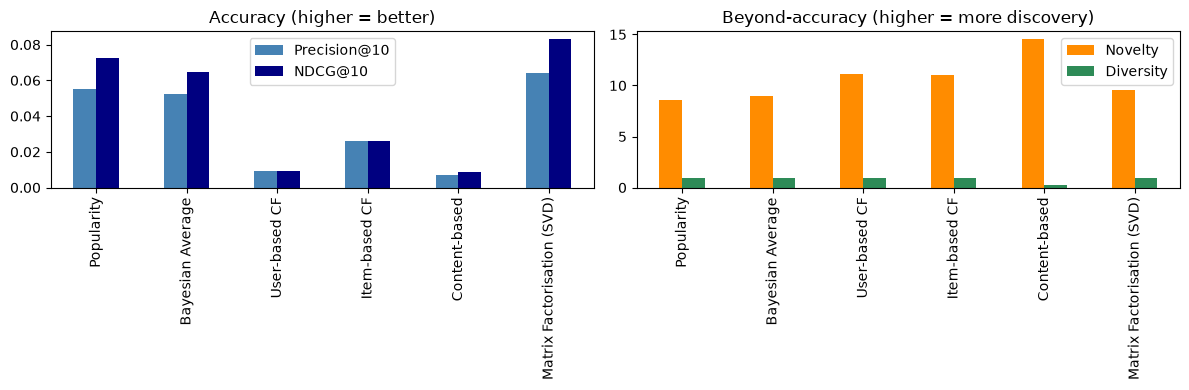

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
table[['Precision@10', 'NDCG@10']].plot.bar(ax=ax[0], color=['steelblue', 'navy'])
ax[0].set_title('Accuracy (higher = better)'); ax[0].set_xlabel('')
table[['Novelty', 'Diversity']].plot.bar(ax=ax[1], color=['darkorange', 'seagreen'])
ax[1].set_title('Beyond-accuracy (higher = more discovery)'); ax[1].set_xlabel('')
plt.tight_layout(); plt.show()